In [12]:
# The codes are derived and edited from the template file from https://neptune.ai/blog/anomaly-detection-in-time-series

from IPython.display import display

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from mpl_toolkits.mplot3d import Axes3D

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
register_matplotlib_converters()
from time import time
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.covariance import EllipticEnvelope

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = np.random.seed(0)

## Isolation Forest and Kmeans

In [13]:
from sklearn.cluster import KMeans

In [14]:
df = pd.read_csv('bmereading_1.csv')

In [15]:
df

,908b,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,eCO2,TVOC,Unnamed: 7,Unnamed: 8
0,1,1,0,1,21,400,0,255,0
1,1,2,0,1,22,400,0,255,0
2,1,3,0,1,23,400,0,255,0
3,1,4,0,1,24,400,0,255,0
4,1,5,0,1,25,400,0,255,0
...,...,...,...,...,...,...,...,...,...
9322,1,9323,2,48,21,466,113,255,0
9323,1,9324,2,48,22,477,115,255,0
9324,1,9325,2,48,23,471,118,255,0
9325,1,9326,2,48,24,473,118,255,0


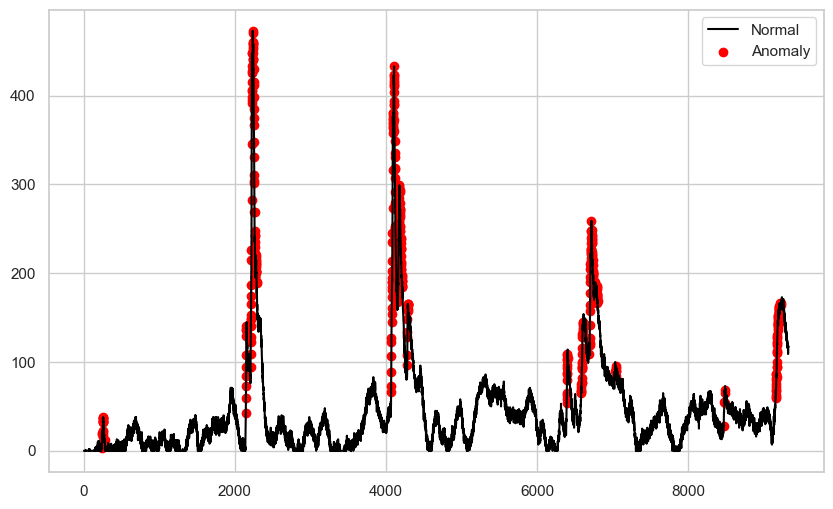

In [16]:
# Isolation forest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest

data = df[['eCO2', 'TVOC']]
scaler = StandardScaler()
np_scaled = scaler.fit_transform(data)
data = pd.DataFrame(np_scaled)

# train isolation forest
model =  IsolationForest(contamination=float(0.05))
model.fit(data) 

data.reset_index(drop=True, inplace=True)

df['anomaly'] = model.predict(data)

# visualization
fig, ax = plt.subplots(figsize=(10,6))

a = df.loc[df['anomaly'] == -1, ['TVOC']] #anomaly

ax.plot(df.index, df['TVOC'], color='black', label = 'Normal')
ax.scatter(a.index,a['TVOC'], color='red', label = 'Anomaly')
plt.legend()
plt.show()

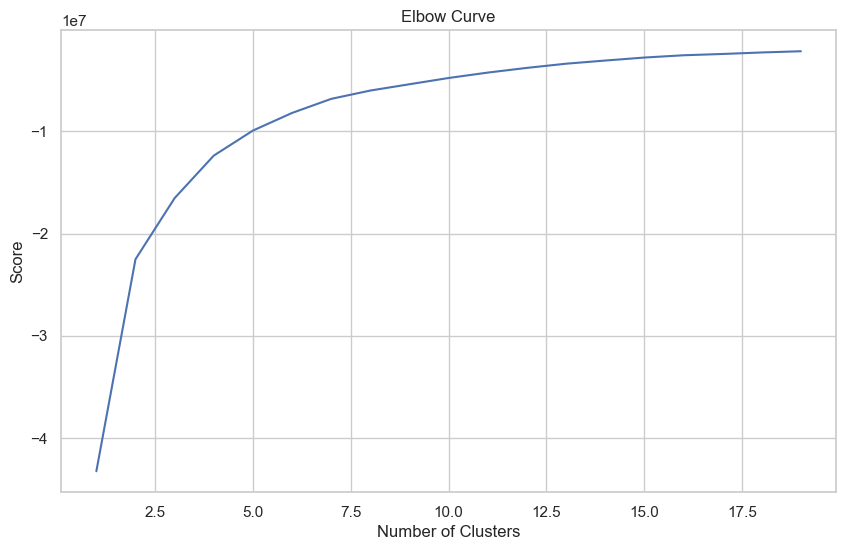

In [17]:
# K-means
data = df[['eCO2', 'TVOC']]
n_cluster = range(1, 20)
kmeans = [KMeans(n_clusters=i).fit(data) for i in n_cluster]
scores = [kmeans[i].score(data) for i in range(len(kmeans))]

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(n_cluster, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

Text(0.5, 1.0, 'K Means')

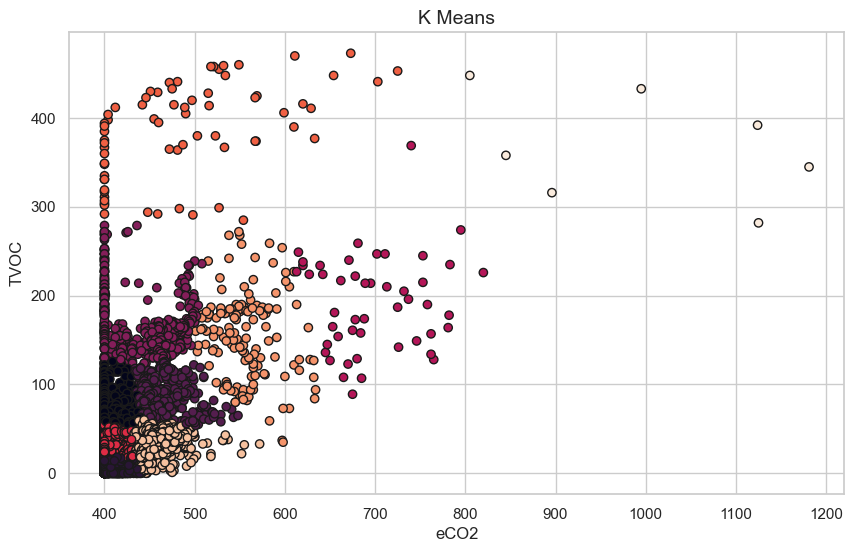

In [18]:
X = df[['eCO2', 'TVOC']]
X = X.reset_index(drop=True)
km = KMeans(n_clusters=10)
km.fit(X)
km.predict(X)
labels = km.labels_
# #Plotting
fig,ax = plt.subplots(figsize=(10,6))
ax.scatter(X.iloc[:,0], X.iloc[:,1], 
          c=labels.astype(np.float), edgecolor="k")
ax.set_xlabel("eCO2")
ax.set_ylabel("TVOC")
plt.title("K Means", fontsize=14)

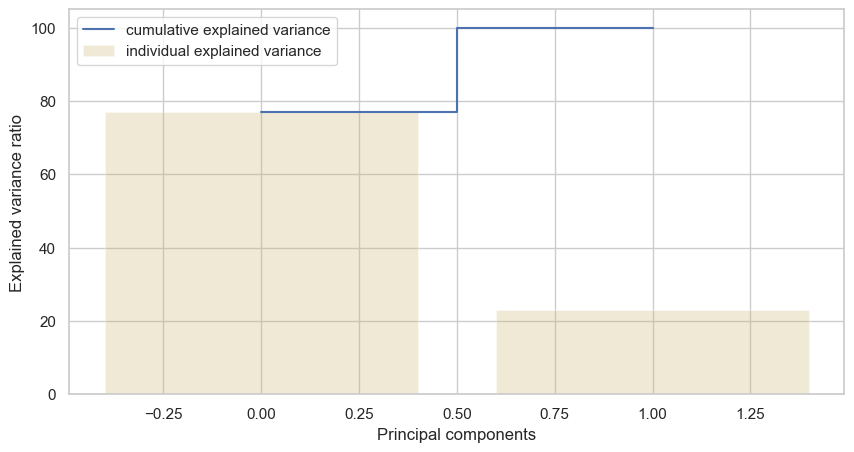

In [19]:
data = df[['eCO2', 'TVOC']]
X = data.values
X_std = StandardScaler().fit_transform(X)
#Calculating Eigenvecors and eigenvalues of Covariance matrix
mean_vec = np.mean(X_std, axis=0)
cov_mat = np.cov(X_std.T)
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
# Create a list of (eigenvalue, eigenvector) tuples
eig_pairs = [ (np.abs(eig_vals[i]),eig_vecs[:,i]) for i in range(len(eig_vals))]

eig_pairs.sort(key = lambda x: x[0], reverse= True)

# Calculation of Explained Variance from the eigenvalues
tot = sum(eig_vals)
var_exp = [(i/tot)*100 for i in sorted(eig_vals, reverse=True)] # Individual explained variance
cum_var_exp = np.cumsum(var_exp) # Cumulative explained variance

plt.figure(figsize=(10, 5))
plt.bar(range(len(var_exp)), var_exp, alpha=0.3, align='center', label='individual explained variance', color = 'y')
plt.step(range(len(cum_var_exp)), cum_var_exp, where='mid',label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.show()

In [20]:
# Take useful feature and standardize them
data = df[['eCO2', 'TVOC']]
X_std = StandardScaler().fit_transform(X)
data = pd.DataFrame(X_std)
# reduce to 2 important features
pca = PCA(n_components=2)
data = pca.fit_transform(data)
# standardize these 2 new features
scaler = StandardScaler()
np_scaled = scaler.fit_transform(data)
data = pd.DataFrame(np_scaled)

In [21]:
kmeans = [KMeans(n_clusters=i).fit(data) for i in n_cluster]
df['cluster'] = kmeans[9].predict(data)
df.index = data.index
df['principal_feature1'] = data[0]
df['principal_feature2'] = data[1]
df['cluster'].value_counts()

cluster
5    3756
6    1887
1    1685
4    1018
3     444
8     255
2     137
0      91
9      50
7       4
Name: count, dtype: int64

In [23]:
# return Series of distance between each point and its distance with the closest centroid
def getDistanceByPoint(data, model):
    distance = pd.Series()
    for i in range(0,len(data)):
        Xa = np.array(data.loc[i])
        Xb = model.cluster_centers_[model.labels_[i]-1]
        distance.at[i]=np.linalg.norm(Xa-Xb)
    return distance

outliers_fraction = 0.05
# get the distance between each point and its nearest centroid. The biggest distances are considered as anomaly
distance = getDistanceByPoint(data, kmeans[9])
number_of_outliers = int(outliers_fraction*len(distance))
threshold = distance.nlargest(number_of_outliers).min()
# anomaly1 contain the anomaly result of the above method Cluster (0:normal, 1:anomaly) 
df['anomaly1'] = (distance >= threshold).astype(int)

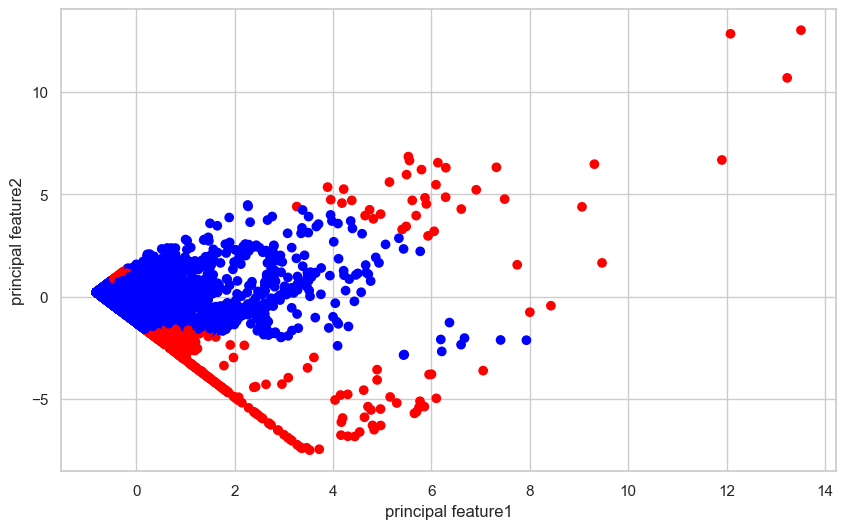

In [24]:
fig, ax = plt.subplots(figsize=(10,6))
colors = {0:'blue', 1:'red'}
ax.scatter(df['principal_feature1'], df['principal_feature2'], c=df["anomaly1"].apply(lambda x: colors[x]))
plt.xlabel('principal feature1')
plt.ylabel('principal feature2')
plt.show()

467


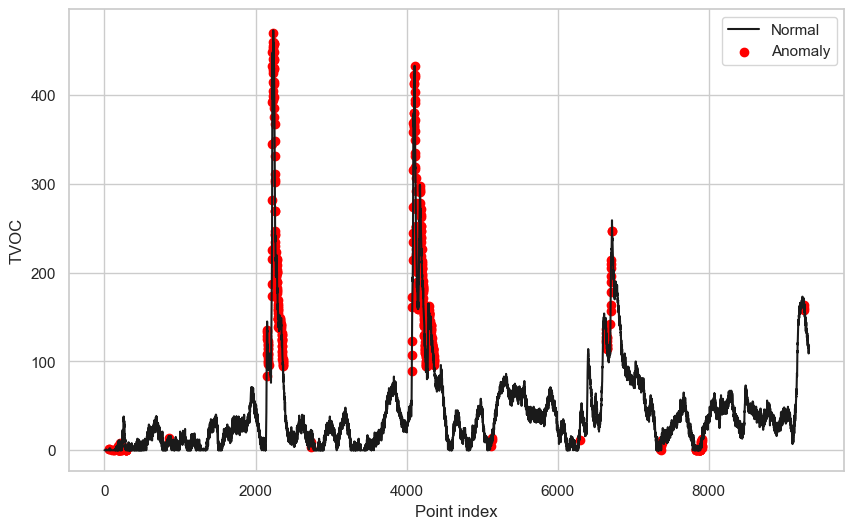

In [25]:
fig, ax = plt.subplots(figsize=(10,6))

a = df.loc[df['anomaly1'] == 1, ['TVOC']] #anomaly
print(len(a))

ax.plot(df['TVOC'], color='k',label='Normal')
ax.scatter(a.index, a['TVOC'], color='red', label='Anomaly')

plt.xlabel('Point index')
plt.ylabel('TVOC')
plt.legend()
plt.show()

467


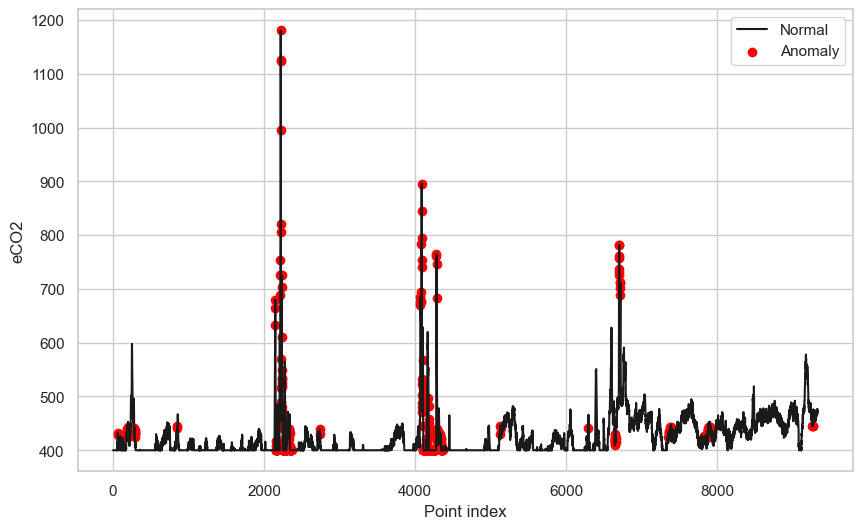

In [26]:
fig, ax = plt.subplots(figsize=(10,6))
a = df.loc[df['anomaly1'] == 1, ['eCO2']] #anomaly
print(len(a))

ax.plot(df['eCO2'], color='k',label='Normal')
ax.scatter(a.index, a['eCO2'], color='red', label='Anomaly')

plt.xlabel('Point index')
plt.ylabel('eCO2')
plt.legend()
plt.show()